This notebook is for testing and development purposes only.
---

Goal: webscrape sites like songsterr.com and tabroom.com to get tab content for songs. Use this to populate the tab cache. Visualize the tab content on the fretboard.

---



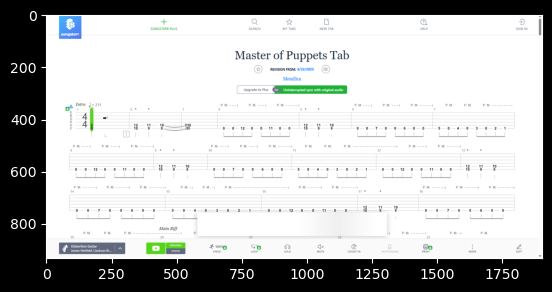

In [ ]:

from bs4 import BeautifulSoup
import selenium
import pandas as pd
import time
from PIL import Image
import matplotlib.pyplot as plt
from selenium import webdriver
from bs4 import BeautifulSoup

test_url = "https://www.songsterr.com/a/wsa/metallica-master-of-puppets-tab-s455118" 

options = webdriver.ChromeOptions()
options.add_argument('--headless')
options.add_argument('--disable-gpu')
options.add_argument('--window-size=1920,1080') # options.add_argument('--window-size=1920,5320')

driver = webdriver.Chrome(options=options)
driver.get(test_url)

# wait for the page to load
time.sleep(5)

#scrape the page
soup = BeautifulSoup(driver.page_source, 'html.parser')

# screenshots the page
driver.save_screenshot('screenshot.png')

# load an image @ screenshot.png
image = plt.imread('screenshot.png')

plt.imshow(image)
plt.show()


In [27]:
import requests
import torch
from PIL import Image
from transformers import AutoFeatureExtractor, AutoModelForImageClassification

# load pre-trained model and feature extractor
feature_extractor = AutoFeatureExtractor.from_pretrained("nanonets/Nanonets-OCR-s")
model = AutoModelForImageClassification.from_pretrained("nanonets/Nanonets-OCR-s")

# load image
img = Image.open("screenshot.png")

# pre-process image
encoding = feature_extractor(images=img, return_tensors="pt")
pixel_values = encoding["pixel_values"].squeeze(0)

# forward pass
outputs = model(pixel_values.unsqueeze(0))

# get predicted class
predicted_class_id = torch.argmax(outputs.logits).item()

# get text from class id
with open("class_labels.txt") as f:
    class_labels = f.readlines()
predicted_text = class_labels[predicted_class_id].strip()

print(predicted_text)


preprocessor_config.json:   0%|          | 0.00/575 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.52k [00:00<?, ?B/s]

ValueError: The checkpoint you are trying to load has model type `qwen2_5_vl` but Transformers does not recognize this architecture. This could be because of an issue with the checkpoint, or because your version of Transformers is out of date.

In [9]:
from PIL import Image

def png_to_pdf(png_file, output_file):
    """
    Converts a PNG image file to a PDF file
    """
    with open(png_file, 'rb') as f:
        img = Image.open(f)
        pdf_path = output_file
        img.save(
            pdf_path, "PDF", resolution=100.0
        )
    return pdf_path

png_to_pdf('screenshot.png', 'HotelCaliforniaSolo.pdf')

'HotelCaliforniaSolo.pdf'

In [12]:
# !pip install pdfplumber

import io
import pdfplumber


with pdfplumber.open("HotelCaliforniaSolo.pdf") as pdf:
    text = "\n".join(page.extract_text() for page in pdf.pages)

print(text[:500])  # shows first part of the tab


In [14]:
from pdf2image import convert_from_path
import pytesseract

# Convert PDF to image(s)
images = convert_from_path("HotelCaliforniaSolo.pdf")

# OCR all pages
text = ""
for img in images:
    text += pytesseract.image_to_string(img) + "\n"

print(text[:500])  # display start of OCR output


“tt Q Ww 0 @Q 2)

SONGSTERR PLUS SEARCH MY TABS NEW TAB HELP SIGN IN

Master of Puppets Tab
@) REVISION FROM: 6/22/2025 ©

Metallica
[upgrade to Plus Uninterrupted sync with original audio
» Intro }=211 P.M. ---4 P.M. ---4 P.M. ------ | P.M. ---4 P.M. ---4 PM jawsiony | P.M. P.M. RUM, sncswseows
eo” ; 2° . 3 4 5° . 6 7
E I
; | | | | | | |
—— | | | |
A 4 (10)
A i— 12 11 10 — (4 12 11 10 |
E - — 10 9 8— AS -—9— 0 — 12—_ 0 —_0 — 11— 0 — 0 — 10 9 8 o—o—7—0—_0—_ 60 —08 i— §-—_ 0 —_ 4—_ 0 —_ 3'\—__ 0 


In [3]:
import re
import json

# Example raw ASCII tab input (you can replace this with any full solo)
ascii_tab = """
e|-----10-----------------------------------------------------------|
B|--------10h12b15---10-12----------7-------------------------------|
G|--/11--------------------9----7-9---7-----------------------------|
D|------------------------------------8----9h11p9p7b8---------------|
A|------------------------------------------------------------------|
E|------------------------------------------------------------------|
"""

# Define string name to number mapping (standard tuning, high e = 1)
string_map = {'e': 1, 'B': 2, 'G': 3, 'D': 4, 'A': 5, 'E': 6}

# Step 1: Split tab into lines
lines = [line for line in ascii_tab.strip().split('\n') if '|' in line]
parsed_strings = {}

# Step 2: Extract tab content from each string
for line in lines:
    name, content = line.split('|', 1)
    name = name.strip()[0]  # First letter: e, B, G, etc.
    parsed_strings[string_map[name]] = re.sub(r'[^0-9\-]', '-', content.strip())

# Step 3: Determine tab length (number of columns)
tab_length = max(len(s) for s in parsed_strings.values())

# Step 4: Build note events per "time slice"
notes = []
i = 0
while i < tab_length:
    note = {"positions": []}
    for string_num, tab_line in parsed_strings.items():
        if i >= len(tab_line):
            continue
        char = tab_line[i]
        if char.isdigit():
            # Check if next char is also a digit (e.g., "10", "11")
            if i + 1 < len(tab_line) and tab_line[i + 1].isdigit():
                fret = int(tab_line[i:i + 2])
                i_offset = 2
            else:
                fret = int(char)
                i_offset = 1
            note["positions"].append({"str": string_num, "fret": fret})
    if note["positions"]:
        notes.append(note)
    i += 1

# Output in tabData.notes format
tab_data = {"notes": notes}
json_path = "tab_data.json"

# Save to file
with open(json_path, "w") as f:
    json.dump(tab_data, f, indent=2)

json_path


'tab_data.json'